# Analysis if NAT2, smoking and bladder cancer

This is the relationship between smoking and bladder cancer risk stratified by NAT2 genotype (rapid vs slow acetylators) according to [Davey Smith 2010](https://journals.sagepub.com/doi/full/10.1177/1745691610383505#bibr33-1745691610383505), reproduced from [Garcia-Closas 2006](https://pmc.ncbi.nlm.nih.gov/articles/PMC1459966/).

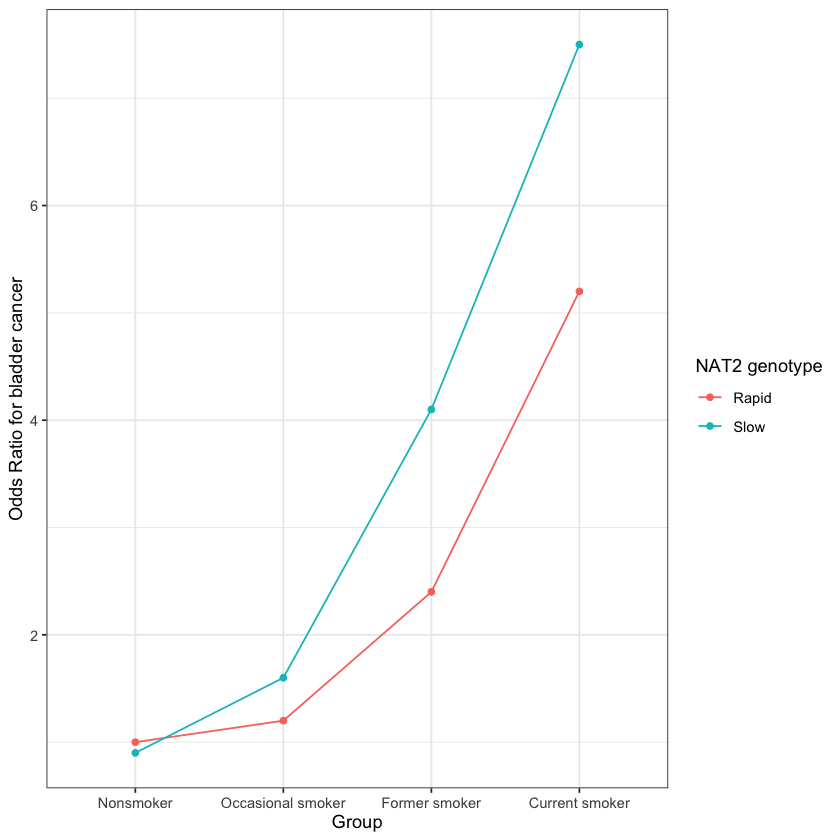

In [ ]:
library(dplyr)
library(ggplot2)
ss <- tibble(
    Group = rep(factor(c("Nonsmoker", "Occasional smoker", "Former smoker", "Current smoker"), levels = c("Nonsmoker", "Occasional smoker", "Former smoker", "Current smoker")), times = 2),
    NAT2_group = rep(c("Rapid", "Slow"), each = 4),
    OR = c(1.0, 1.2, 2.4, 5.2, 0.9, 1.6, 4.1, 7.5)
) 
ggplot(ss, aes(x = Group, y = OR, group = NAT2_group, color = NAT2_group)) +
    geom_line() +
    geom_point() +
    theme_bw() +
    labs(y = "Risk Ratio for bladder cancer", color = "NAT2 genotype")

Generate a DAG that could explain this association:

![NAT2 and bladder cancer risk](dag.png)

Note that no interaction is required, but the effect of NAT2 on carcinogen levels is a relative effect, meaning that fast metabolisers will reduce carcinogen levels at a faster rate than slow metabolisers, but the additive change in carcinogen levels will be dependent on the initial level.

The model will look like:

$$
\text{logit}(P(Y=1)) = \beta_0 + \beta_{H,Y} H + \beta_{U,Y} U + E_Y
$$

Carcinogen intake:

$$
H_{intake} = \beta_{S,H} C + \beta_{U,H} U + E_H
$$

Carcinogen levels:

$$
H = \beta_{G_N,H} \times N \times H_{intake}
$$

NAT2 activity / levels:

$$
N = \beta_{G_N,N} G_N + E_N
$$

Smoking is represented as cigarettes per day, where G_I influences ever/never smoking and G_C influences number of cigarettes smoked per day among smokers.

$$
logit(P(S=1)) = \beta_{G_I,S} G_I + \beta_{U,S} U + E_S
$$

$C_i = 0$ if $S_i = 0$, otherwise 

$$
C = \beta_{G_C,C} G_C + \beta_{U,C} U + E_C
$$



where

- $N$ is the NAT2 gene activity level
- $H$ is the level of heterocyclic amines / carcinogens
- $S$ is smoking initiation (0 for never, 1 for ever)
- $C$ is the number of cigarettes smoked per day
- $Y$ is bladder cancer status (0/1)
- $G_1$ is the NAT2 genotype (2 for rapid, 1 for slow)



That describes the data generating model in the simulation below. Function for the data generating model:



In [ ]:
dgm <- function(b_0, b_hy, b_uy, b_sh, b_nh, b_gcc, b_gis, b_gnn, b_us, b_uc, b_uh, n) {
    U <- runif(n)
    Gc <- rbinom(n, 2, 0.5)
    Gi <- rbinom(n, 2, 0.5)
    Gn <- rbinom(n, 1, 0.5) + 1
    logit_S <- b_gis * Gi + b_us * U + rnorm(n)
    S <- rbinom(n, 1, exp(logit_S) / (1 + exp(logit_S)))
    C <- ifelse(S == 0, 0, rpois(n, lambda = b_gcc * Gc + b_uc * U))
    N <- b_gnn * Gn + rnorm(n)
    H_intake <- b_sh * C + b_uh * U + rnorm(n)
    H <- H_intake * N * b_nh
    logit_p <- b_0 + b_hy * H + b_uy * U
    p <- exp(logit_p) / (1 + exp(logit_p))
    Y <- rbinom(n, 1, p)
    Ccat <- cut(C, breaks=c(-Inf, 0, 1, 2, 3, Inf), labels=c("0", "1", "2", "3", "4+"))    
    tibble(Y = Y, H = H, U = U, S = S, C = C, N = N, Gc = Gc, Gi = Gi, Gn = Gn, Ccat = Ccat)
}

And this is the estimation model - the influence of smoking on bladder cancer stratified by NAT2 genotype

In [4]:
estimation_gc2005 <- function(data) {
    model <- glm(Y ~ C * Gn, data = data, family = binomial)
    summary(model)
}

Example dataset with no confounding:

In [5]:
dat <- dgm(
    b_0 = -3,
    b_hy = 0.5,
    b_uy = 0,
    b_sh = 0.4,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 1.0,
    b_us = 0,
    b_uc = 0,
    b_uh = 0,
    n = 1000000
)

str(dat)

# Bladder cancer prevalence
table(dat$Y)

# Smoking behaviour categories
table(dat$Ccat)

tibble [1,000,000 × 10] (S3: tbl_df/tbl/data.frame)
 $ Y   : int [1:1000000] 0 0 0 0 1 0 0 0 0 0 ...
 $ H   : num [1:1000000] 0.0903 -0.3213 -0.1779 0.3675 -0.1627 ...
 $ U   : num [1:1000000] 0.162 0.595 0.3 0.114 0.371 ...
 $ S   : int [1:1000000] 1 0 0 1 0 1 1 1 1 1 ...
 $ C   : num [1:1000000] 1 0 0 0 0 0 0 2 0 1 ...
 $ N   : num [1:1000000] 2.396 0.986 2.694 1.127 1.235 ...
 $ Gc  : int [1:1000000] 1 2 1 2 2 0 0 2 0 1 ...
 $ Gi  : int [1:1000000] 1 1 1 1 0 0 2 1 2 2 ...
 $ Gn  : num [1:1000000] 2 2 2 1 1 1 1 2 2 2 ...
 $ Ccat: Factor w/ 5 levels "0","1","2","3",..: 2 1 1 1 1 1 1 3 1 2 ...



     0      1 
949446  50554 


     0      1      2      3     4+ 
635913 172644 108791  51907  30745 

Estimation:

In [6]:
estimation_gc2005(dat)


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -3.000089   0.017225 -174.172  < 2e-16 ***
C           -0.007066   0.012443   -0.568    0.570    
Gn           0.013120   0.010854    1.209    0.227    
C:Gn         0.048186   0.007732    6.232  4.6e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 400286  on 999999  degrees of freedom
Residual deviance: 399936  on 999996  degrees of freedom
AIC: 399944

Number of Fisher Scoring iterations: 5


So this generates a G x smoking interaction on breast cancer with no marginal effect. Plot:

In [24]:
estimation2 <- function(data) {
    total_cases <- sum(data$Y)
    risk_baseline <- sum(data$Y[data$Ccat == 0 & data$Gn == 2]) / sum(data$Ccat == 0 & data$Gn == 2)
    group_by(data, Gn, Ccat) %>%
        do({
            cases <- sum(.$Y)
            n <- nrow(.)
            tibble(
                cases = cases,
                risk = cases / n,
                RR = risk / risk_baseline
            )
        })
}
estimation2(dat)


Gn,Ccat,cases,risk,RR
<dbl>,<fct>,<int>,<dbl>,<dbl>
1,0,15316,0.04821477,0.9936795
1,1,4260,0.04930327,1.0161129
1,2,2799,0.05130226,1.0573109
1,3,1401,0.05415330,1.1160693
1,4+,909,0.05854318,1.2065423
2,0,15442,0.04852145,1.0000000
2,1,4602,0.05336271,1.0997756
2,2,3126,0.05764125,1.1879539
2,3,1617,0.06210631,1.2799765



Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -2.854711   0.017638 -161.853  < 2e-16 ***
C            0.011335   0.007081    1.601 0.109434    
Gn           0.164012   0.010910   15.033  < 2e-16 ***
C:Gn         0.016247   0.004360    3.726 0.000195 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 522031  on 999999  degrees of freedom
Residual deviance: 521117  on 999996  degrees of freedom
AIC: 521125

Number of Fisher Scoring iterations: 5



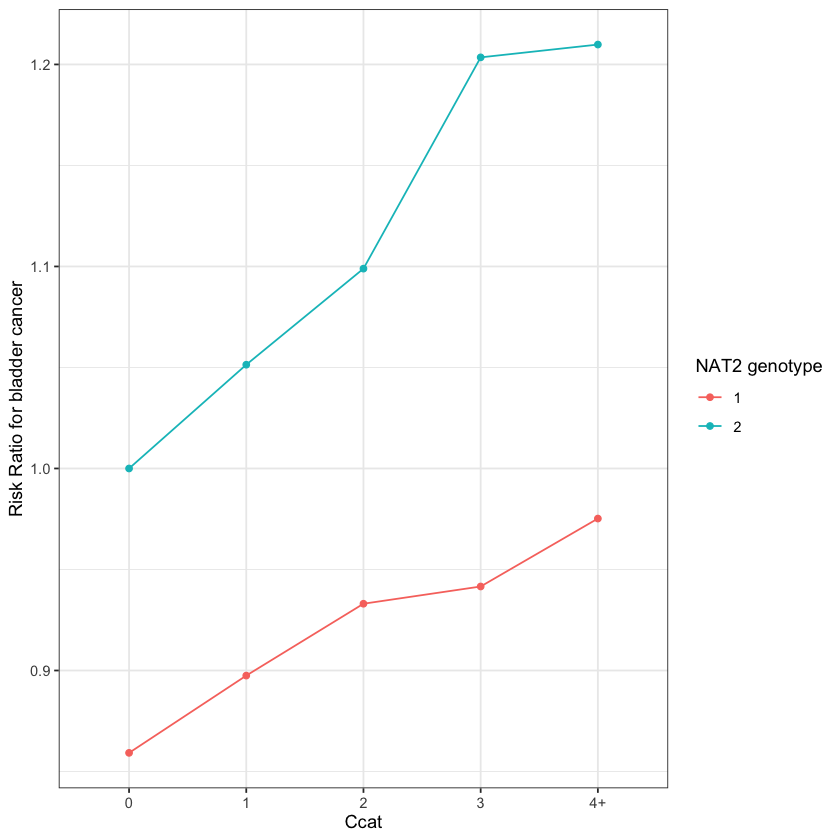

In [79]:
plot_rr <- function(data) {
    print(estimation_gc2005(data))
    rr <- estimation2(data)
    ggplot(rr, aes(x = Ccat, y = RR, group = Gn, color = factor(Gn))) +
        geom_line() +
        geom_point() +
        theme_bw() +
        labs(y = "Risk Ratio for bladder cancer", color = "NAT2 genotype")
}
plot_rr(dat)

Change simulation parameters to come up with larger RRs:


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -3.011141   0.016175 -186.157  < 2e-16 ***
C            0.280407   0.008422   33.296  < 2e-16 ***
Gn           0.043092   0.010141    4.249 2.14e-05 ***
C:Gn         0.124561   0.005214   23.888  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 541359  on 999999  degrees of freedom
Residual deviance: 510120  on 999996  degrees of freedom
AIC: 510128

Number of Fisher Scoring iterations: 5



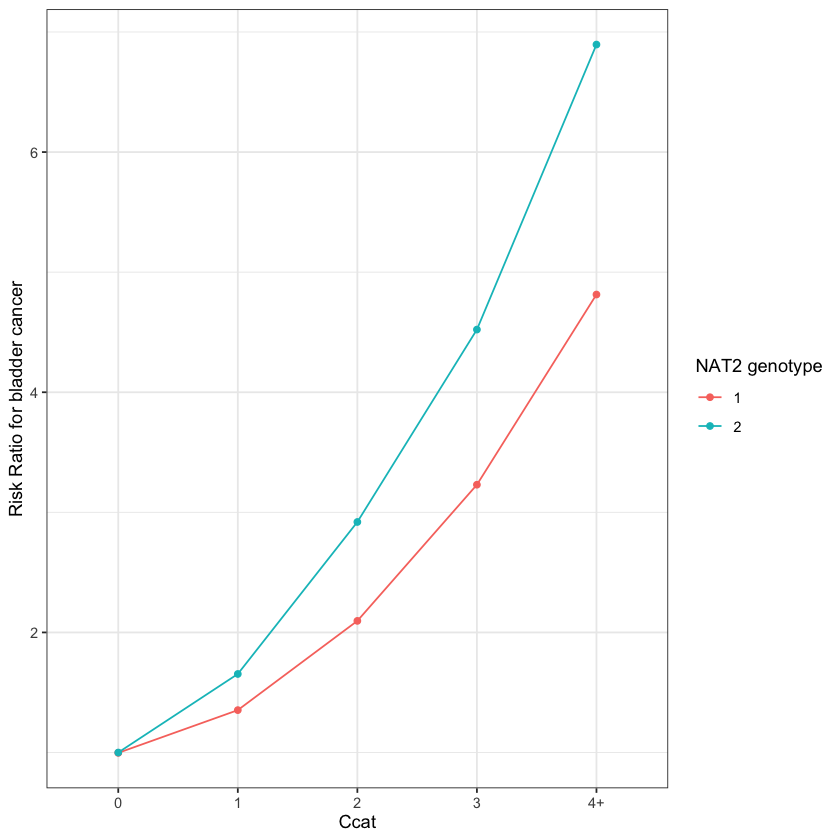

In [92]:
dgm(
    b_0 = -3,
    b_hy = 1.3,
    b_uy = 0,
    b_sh = 2,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 0,
    b_uc = 0,
    b_uh = 0,
    n = 1000000
) %>% plot_rr()

That's pretty close to the empirical results.

Can the result be explained by other models, such as if smoking is not causal but is confounded?


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -2.054536   0.013496 -152.231   <2e-16 ***
C            0.104103   0.005081   20.488   <2e-16 ***
Gn          -0.008766   0.008539   -1.027    0.305    
C:Gn         0.000905   0.003216    0.281    0.778    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 782584  on 999999  degrees of freedom
Residual deviance: 778436  on 999996  degrees of freedom
AIC: 778444

Number of Fisher Scoring iterations: 4



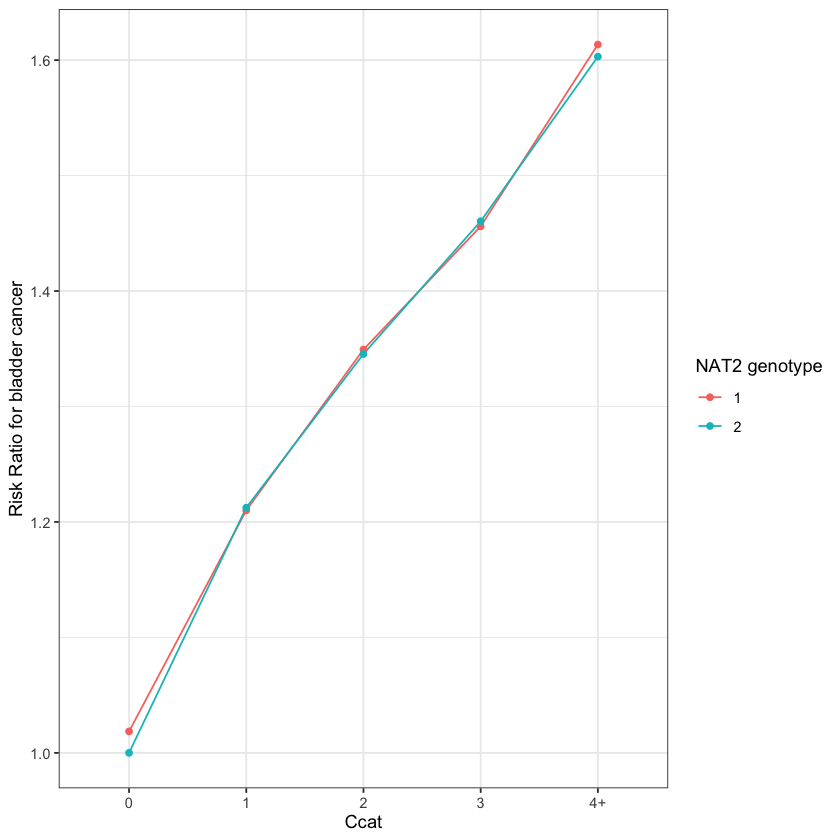

In [91]:
# Confounding of smoking and H
dgm(
    b_0 = -3,
    b_hy = 0,
    b_uy = 2,
    b_sh = 2,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 2,
    b_uc = 2,
    b_uh = 0,
    n = 1000000
) %>% plot_rr()

Now the influence of carcinogens on bladder cancer is 0 but smoking - bladder cancer is confounded, i.e. there is no direct path from smoking to bladder cancer. The interaction disappears.


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -1.774290   0.010983 -161.545  < 2e-16 ***
C            0.115373   0.004208   27.416  < 2e-16 ***
Gn           0.257791   0.006800   37.909  < 2e-16 ***
C:Gn         0.009533   0.002616    3.645 0.000268 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1102201  on 999999  degrees of freedom
Residual deviance: 1089070  on 999996  degrees of freedom
AIC: 1089078

Number of Fisher Scoring iterations: 4



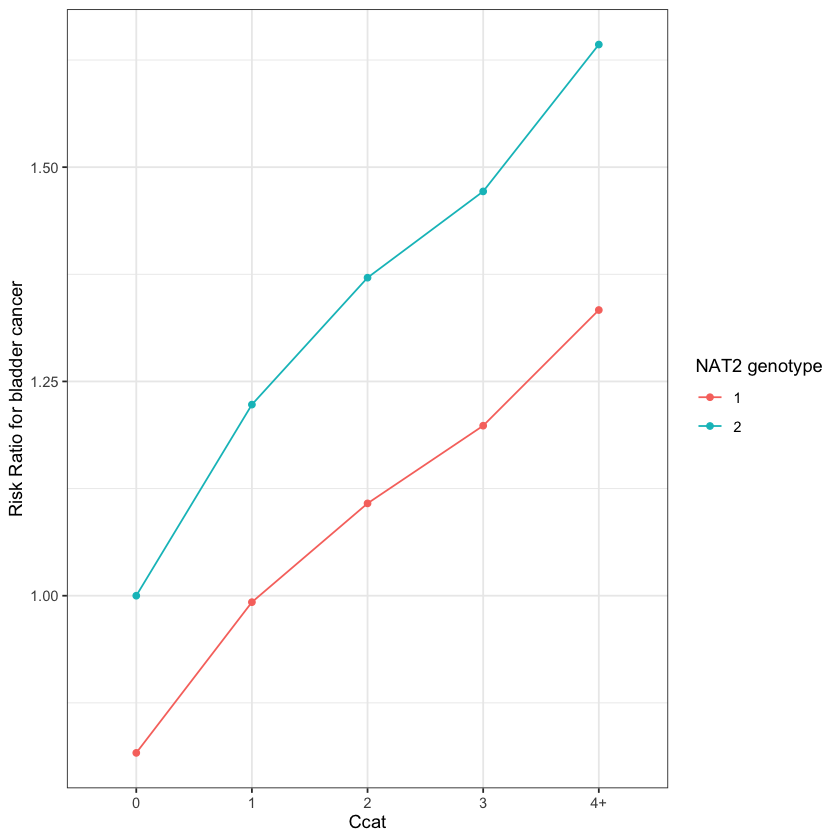

In [102]:
# Confounding of smoking and H
dgm(
    b_0 = -3,
    b_hy = 4,
    b_uy = 2,
    b_sh = 0,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 2,
    b_uc = 2,
    b_uh = 2,
    n = 1000000
) %>% plot_rr()

Now smoking has no influence on carcinogens but smoking - carcinogen is confounded.

In [83]:
dat <- dgm(
    b_0 = -3,
    b_hy = 2,
    b_uy = 0,
    b_sh = 0,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 2,
    b_uc = 2,
    b_uh = 2,
    n = 1000000
)
estimation_gc2005(dat)


Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error  z value Pr(>|z|)    
(Intercept) -2.891123   0.017711 -163.240  < 2e-16 ***
C            0.014434   0.007093    2.035 0.041848 *  
Gn           0.184072   0.010936   16.832  < 2e-16 ***
C:Gn         0.014876   0.004359    3.413 0.000643 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 520799  on 999999  degrees of freedom
Residual deviance: 519752  on 999996  degrees of freedom
AIC: 519760

Number of Fisher Scoring iterations: 5



Call:
glm(formula = Y ~ C * Gn, family = binomial, data = data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.407512   0.008153 -49.981  < 2e-16 ***
C            0.046493   0.005921   7.852 4.11e-15 ***
Gn          -0.408894   0.005302 -77.124  < 2e-16 ***
C:Gn         0.190083   0.003803  49.977  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1248525  on 999999  degrees of freedom
Residual deviance: 1211903  on 999996  degrees of freedom
AIC: 1211911

Number of Fisher Scoring iterations: 4



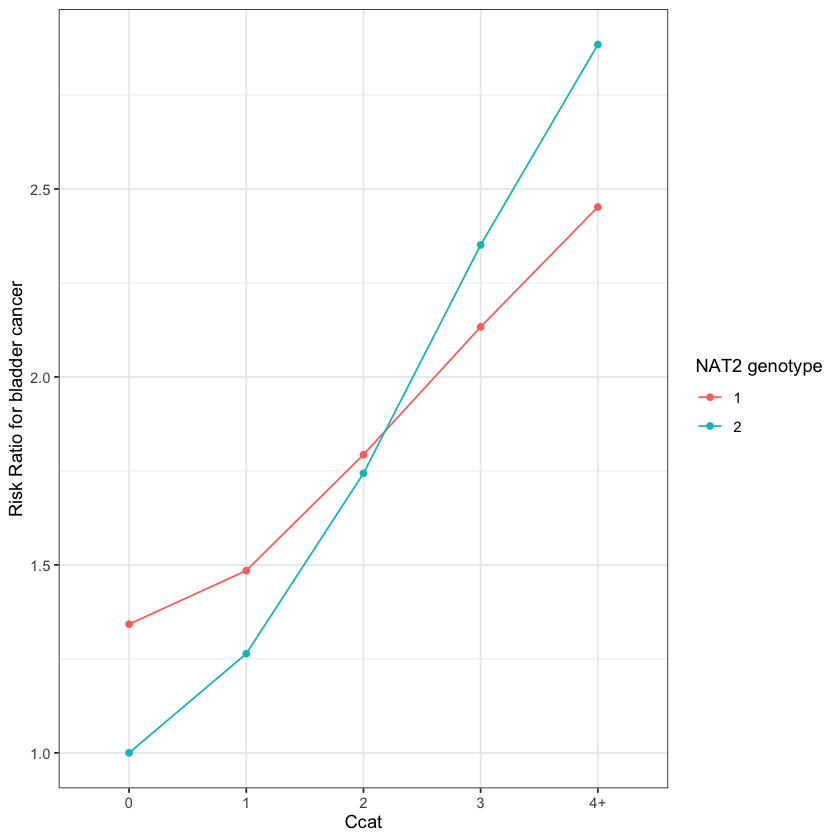

In [90]:
# Confounding of smoking and H
dgm(
    b_0 = -3,
    b_hy = 2,
    b_uy = 5,
    b_sh = 2,
    b_nh = 0.2,
    b_gcc = 1.0,
    b_gis = 1.0,
    b_gnn = 0.4,
    b_us = 0,
    b_uc = 0,
    b_uh = -8,
    n = 1000000
) %>% plot_rr()

In [ ]:

# Trying to find parameters that give the same pattern as in the data but there is no causal effect of smoking on h.

search_pattern <- functioon(b_uy, b_us, b_uc, b_uh, b_hy, b_nh, n=10000) {
    dat <- dgm(
        b_0 = -3,
        b_hy = b_hy,
        b_uy = b_uy,
        b_sh = 0, # Needs to be set to zero
        b_nh = 0.2,
        b_gcc = 1.0,
        b_gis = 1.0,
        b_gnn = 0.4,
        b_us = b_us,
        b_uc = b_uc,
        b_uh = b_uh,
        n = 1000000
    )

    # Need 
    # - RR ~= 1 for Gn = 2, Ccat = 0
    # - beta_C

    rr <- estimation2(dat)
}
